# Laboratorio de regresión 3 — Resumen
**David · 07 de septiembre de 2026**

El EDA permite elegir modelos a partir del significado, distribución y relación de las variables; después se validan sus resultados.

### 1. Dataset y variables
Archivo: *Heart Prediction Quantum Dataset.csv*. Tiene 500 filas, cinco predictores y la etiqueta binaria `HeartDisease`. El archivo no documenta quién recolectó las observaciones, el muestreo, el año ni el lugar.

| Variable | Significado y tipo | Valores esperados |
|---|---|---|
| Age | Edad; entero | No negativa; orientativamente 0–110 años |
| Gender | Sexo registrado; categoría nominal | Hombre / Mujer |
| BloodPressure | Presión arterial; numérica continua | Positiva; referencia orientativa del ejercicio: 70–200 mmHg |
| Cholesterol | Colesterol; numérica, registrada en enteros | Positivo; referencia orientativa: 100–400 mg/dL |
| HeartRate | Frecuencia cardiaca; numérica, registrada en enteros | Positiva; referencia orientativa: 40–200 lpm |
| HeartDisease | Enfermedad cardiaca; categoría binaria | 0 = no, 1 = sí |

Estos rangos orientan la revisión; no son umbrales para diagnosticar ni eliminar filas. El objetivo sería clasificar `HeartDisease`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Heart Prediction Quantum Dataset.csv')
print('Filas y columnas:', df.shape)
df.info()
df.head()

Filas y columnas: (500, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Age            500 non-null    int64 
 1   Gender         500 non-null    object
 2   BloodPressure  500 non-null    object
 3   Cholesterol    500 non-null    int64 
 4   HeartRate      500 non-null    int64 
 5   HeartDisease   500 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 23.6+ KB


,Age,Gender,BloodPressure,Cholesterol,HeartRate,HeartDisease
0,68,Hombre,105.00,191,107,1
1,58,Mujer,97.00,249,89,0
2,44,Mujer,93.00,190,82,1
3,72,Hombre,93.00,183,101,1
4,37,Mujer,145.00,166,103,1


### 2. Detectar problemas
Revisamos tipos, faltantes, duplicados y distribuciones. La coma decimal de `BloodPressure` y las variantes de `Gender` son errores de formato.

Gender: ['Hombre   ' 'Mujer' 'ombre' 'mujer' 'MUjer' 'MUJER' 'Mujer{' 'Hombre}'
 'Hombre']
Faltantes: {'Age': 0, 'Gender': 0, 'BloodPressure': 0, 'Cholesterol': 0, 'HeartRate': 0, 'HeartDisease': 0}
Duplicados: 0
Presiones con coma: 126


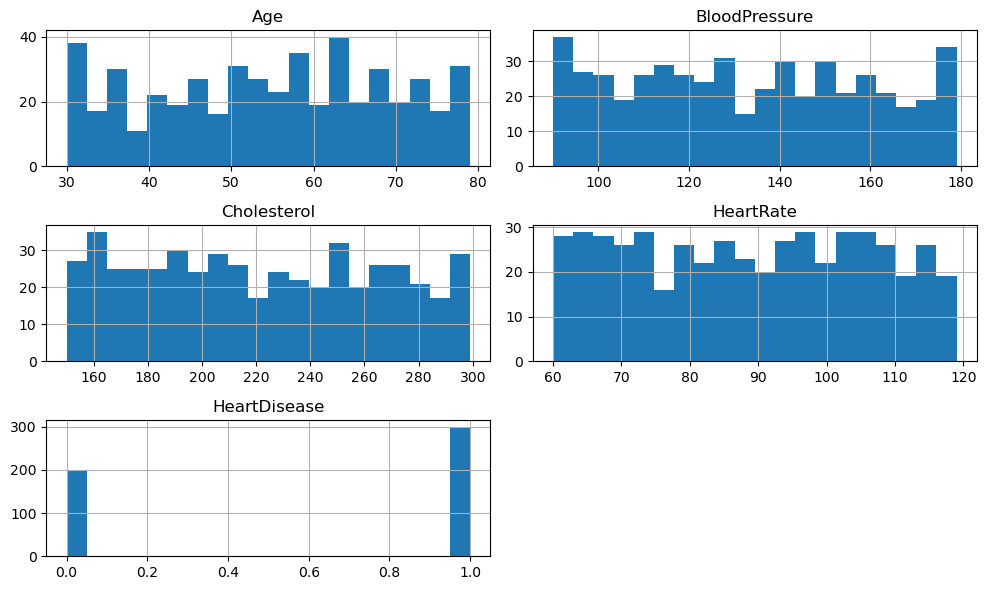

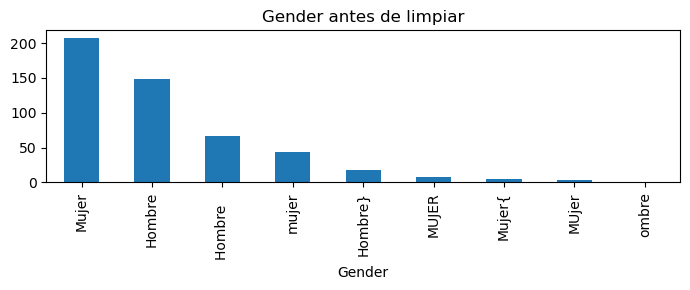

In [3]:
print('Gender:', df['Gender'].unique())
print('Faltantes:', df.isna().sum().to_dict())
print('Duplicados:', df.duplicated().sum())
print('Presiones con coma:', df['BloodPressure'].str.contains(',').sum())

# Conversión temporal para visualizar la presión sin modificar el original
vista = df.drop(columns='Gender').copy()
vista['BloodPressure'] = pd.to_numeric(df['BloodPressure'].str.replace(',', '.', regex=False))
vista.hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()
df['Gender'].value_counts().plot.bar(title='Gender antes de limpiar', figsize=(7, 3))
plt.tight_layout()
plt.show()

### 3. Limpiar
Corregimos las comas decimales y normalizamos `Gender`: minúsculas → quitar caracteres finales → corregir `ombre` → hombre = 1 y mujer = 0. Luego eliminamos duplicados y faltantes, como pide el ejercicio.

In [4]:
antes = len(df)
df['BloodPressure'] = pd.to_numeric(df['BloodPressure'].str.replace(',', '.', regex=False))
gender = df['Gender'].str.lower()
print('Tras lower:', gender.unique())
gender = gender.str.rstrip(' {}')
print('Tras rstrip:', gender.unique())
gender.loc[gender == 'ombre'] = 'hombre'
df['Gender'] = gender.map({'hombre': 1, 'mujer': 0})
df = df.drop_duplicates().dropna()
df['Gender'] = df['Gender'].astype(int)
print(f'Filas: {antes} → {len(df)}; Gender final: {df["Gender"].unique()}')
df.dtypes

Tras lower: ['hombre   ' 'mujer' 'ombre' 'mujer{' 'hombre}' 'hombre']
Tras rstrip: ['hombre' 'mujer' 'ombre']
Filas: 500 → 500; Gender final: [1 0]


Age                int64
Gender             int64
BloodPressure    float64
Cholesterol        int64
HeartRate          int64
HeartDisease       int64
dtype: object

### 4. Verificar y describir
Repetimos histogramas, calculamos estadísticas y buscamos atípicos con el criterio de 1.5 × IQR. Las frecuencias describen las dos variables categóricas.

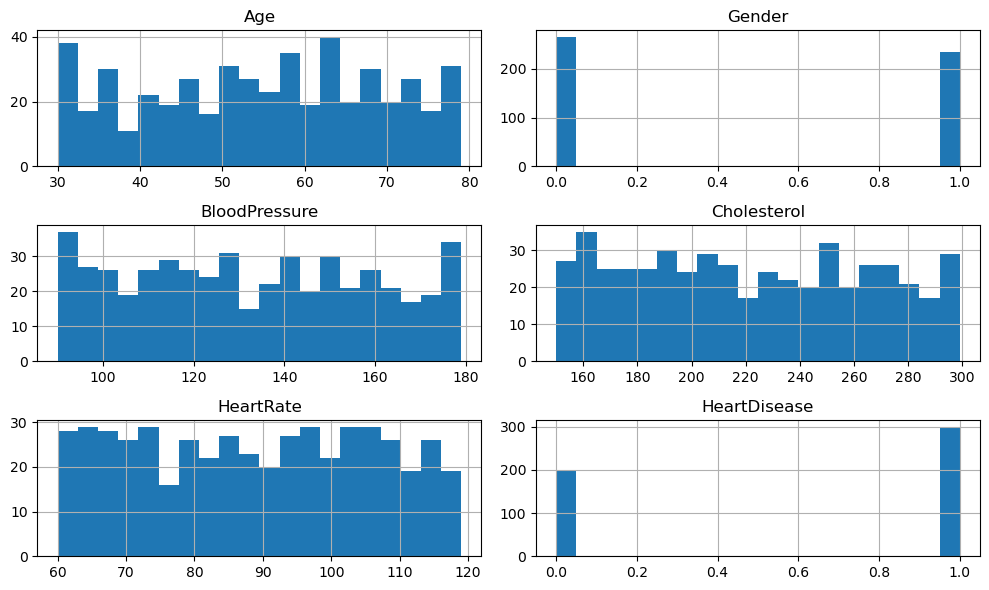

,mean,median,std,min,max,atípicos
Age,54.86,55.0,14.32,30.0,79.0,0
BloodPressure,132.87,132.0,26.42,90.0,179.0,0
Cholesterol,221.50,221.0,43.86,150.0,299.0,0
HeartRate,88.77,89.0,17.42,60.0,119.0,0


In [5]:
df.hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

numericas = ['Age', 'BloodPressure', 'Cholesterol', 'HeartRate']
estadisticas = df[numericas].agg(['mean', 'median', 'std', 'min', 'max']).T
q1, q3 = df[numericas].quantile(.25), df[numericas].quantile(.75)
iqr = q3 - q1
estadisticas['atípicos'] = ((df[numericas] < q1 - 1.5 * iqr) |
                           (df[numericas] > q3 + 1.5 * iqr)).sum()
estadisticas.round(2)

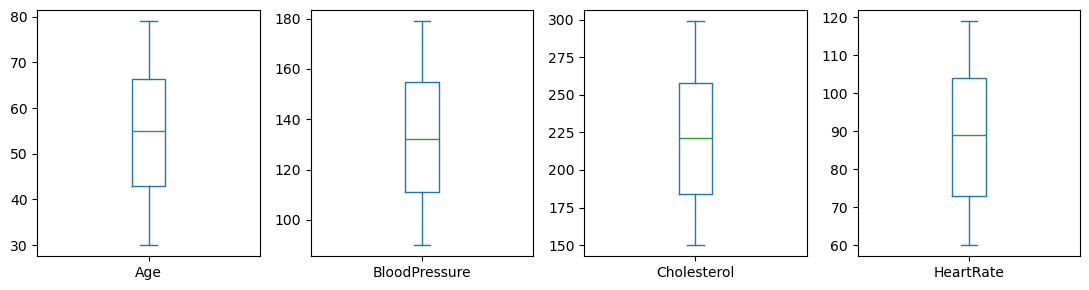


Gender — valores únicos: [np.int64(0), np.int64(1)]
        Frecuencia     %
Gender                  
0              266  53.2
1              234  46.8

HeartDisease — valores únicos: [np.int64(0), np.int64(1)]
              Frecuencia     %
HeartDisease                  
0                    200  40.0
1                    300  60.0


HeartDisease,0,1,All
Gender,,,
0,105,161,266
1,95,139,234
All,200,300,500


In [6]:
df[numericas].plot.box(subplots=True, layout=(1, 4), figsize=(11, 3), sharey=False)
plt.tight_layout()
plt.show()

# 0 = mujer / sin enfermedad; 1 = hombre / con enfermedad
for col in ['Gender', 'HeartDisease']:
    frecuencia = df[col].value_counts().sort_index()
    print(f'\n{col} — valores únicos: {sorted(df[col].unique())}')
    print(pd.DataFrame({'Frecuencia': frecuencia, '%': np.round(100 * frecuencia / len(df), 1)}))

pd.crosstab(df['Gender'], df['HeartDisease'], margins=True)

In [7]:
# Porcentaje de cada diagnóstico dentro de cada sexo
(pd.crosstab(df['Gender'], df['HeartDisease'], normalize='index') * 100).round(1)

HeartDisease,0,1
Gender,,
0,39.5,60.5
1,40.6,59.4


### Conclusión
Se corrigieron **126 presiones con coma decimal** y **9 variantes de Gender**, conservando las **500 filas**. Quedan 266 mujeres y 234 hombres; `HeartDisease` contiene 300 positivos y 200 negativos. No hay faltantes, duplicados ni atípicos según IQR.

Las distribuciones numéricas son aproximadamente uniformes. Esto no demuestra por sí solo que sean datos simulados; falta documentación sobre su recolección. Para predecir la etiqueta binaria se podría evaluar una regresión logística.

**Referencias del ejercicio:** [dataset en Kaggle](https://www.kaggle.com/datasets/shantanugarg274/heart-prediction-dataset-quantum); ACC/AHA (2017), NCEP/ATP III y AHA, *Target Heart Rates*.

### 5. Regresión logística — elegir las variables
`X` contiene las cinco columnas predictoras. `y` contiene la respuesta real: `HeartDisease` (0 o 1).

In [7]:
from sklearn.linear_model import LogisticRegression

X = df.drop(columns='HeartDisease')
y = df['HeartDisease']

**Entrenar el modelo**
Creamos un solo modelo con `C=0.1`. `fit(X, y)` aprende la relación entre las variables y la respuesta. `max_iter=1000` es el límite de iteraciones del ajuste.

In [8]:
modelo = LogisticRegression(C=0.1, max_iter=1000)
modelo.fit(X, y)
print('Modelo entrenado.')

Modelo entrenado.


**Ver los coeficientes**
B0 es el intercepto. Cada una de las cinco variables tiene su propio coeficiente, mostrado junto a su nombre.

In [9]:
B0 = modelo.intercept_[0]
print('B0:', B0)

coeficientes = pd.Series(modelo.coef_[0], index=X.columns)
coeficientes

B0: 7.063223421435157


Age              0.050335
Gender          -0.020409
BloodPressure   -0.015845
Cholesterol     -0.025107
HeartRate       -0.017855
dtype: float64

**Obtener las probabilidades**
`predict_proba(X)` devuelve dos columnas: probabilidad de 0 y probabilidad de 1. `[:, 1]` selecciona la segunda columna para todas las filas. Mostramos las primeras cinco probabilidades.

In [10]:
probabilidades = modelo.predict_proba(X)
probabilidad = probabilidades[:, 1]
probabilidad[:5]

array([0.8905069 , 0.64677994, 0.82777169, 0.94242643, 0.65050711])

### 6. Clasificar y contar los resultados
Para cada umbral, una probabilidad mayor o igual se convierte en **1**; una menor, en **0**. `.astype(int)` convierte verdadero/falso en 1/0.

- **TP:** real 1 y predicción 1.
- **TN:** real 0 y predicción 0.
- **FP:** real 0 y predicción 1.
- **FN:** real 1 y predicción 0.

`&` significa “y”; `.sum()` cuenta las filas que cumplen ambas condiciones. Estos conteos usan las mismas 500 filas del entrenamiento.

**Umbral 0.3:** predecimos 1 cuando la probabilidad es al menos 30%.

In [11]:
umbral = 0.3
prediccion = (probabilidad >= umbral).astype(int)
prediccion[:5]

array([1, 1, 1, 1, 1])

**Contar TP, TN, FP y FN para el umbral 0.3.** Comparamos las predicciones anteriores con la respuesta real `y`.

In [12]:
print('TP:', ((y == 1) & (prediccion == 1)).sum())
print('TN:', ((y == 0) & (prediccion == 0)).sum())
print('FP:', ((y == 0) & (prediccion == 1)).sum())
print('FN:', ((y == 1) & (prediccion == 0)).sum())

TP: 281
TN: 73
FP: 127
FN: 19


**Umbral 0.5:** predecimos 1 cuando la probabilidad es al menos 50%.

In [13]:
umbral = 0.5
prediccion = (probabilidad >= umbral).astype(int)
prediccion[:5]

array([1, 1, 1, 1, 1])

**Contar TP, TN, FP y FN para el umbral 0.5.** Comparamos las predicciones anteriores con la respuesta real `y`.

In [14]:
print('TP:', ((y == 1) & (prediccion == 1)).sum())
print('TN:', ((y == 0) & (prediccion == 0)).sum())
print('FP:', ((y == 0) & (prediccion == 1)).sum())
print('FN:', ((y == 1) & (prediccion == 0)).sum())

TP: 238
TN: 127
FP: 73
FN: 62


**Umbral 0.8:** predecimos 1 cuando la probabilidad es al menos 80%.

In [15]:
umbral = 0.8
prediccion = (probabilidad >= umbral).astype(int)
prediccion[:5]

array([1, 0, 1, 1, 0])

**Contar TP, TN, FP y FN para el umbral 0.8.** Comparamos las predicciones anteriores con la respuesta real `y`.

In [16]:
print('TP:', ((y == 1) & (prediccion == 1)).sum())
print('TN:', ((y == 0) & (prediccion == 0)).sum())
print('FP:', ((y == 0) & (prediccion == 1)).sum())
print('FN:', ((y == 1) & (prediccion == 0)).sum())

TP: 134
TN: 184
FP: 16
FN: 166
